In [1]:
import csv
#import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


file_path = '/content/anxiety_depression_data.csv'

# Создание базы данных
conn = sqlite3.connect('mentalhealth.db')
cursor = conn.cursor()

# Создание таблицы "mentalhealth" для загрузки датасета
cursor.execute('''CREATE TABLE IF NOT EXISTS mentalhealth (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    Age INTEGER NOT NULL,
    Gender TEXT NOT NULL,
    Education_Level TEXT NOT NULL,
    Employment_Status TEXT NOT NULL,
    Sleep_Hours FLOAT NOT NULL,
    Physical_Activity_Hrs FLOAT NOT NULL,
    Social_Support_Score INTEGER NOT NULL,
    Anxiety_Score INTEGER NOT NULL,
    Depression_Score INTEGER NOT NULL,
    Stress_Level INTEGER NOT NULL,
    Family_History_Mental_Illness INTEGER NOT NULL,
    Chronic_Illnesses INTEGER NOT NULL,
    Medication_Use TEXT,
    Therapy INTEGER NOT NULL,
    Meditation INTEGER NOT NULL,
    Substance_Use TEXT,
    Financial_Stress INTEGER NOT NULL,
    Work_Stress INTEGER NOT NULL,
    Self_Esteem_Score INTEGER NOT NULL,
    Life_Satisfaction_Score INTEGER NOT NULL,
    Loneliness_Score INTEGER NOT NULL
)''')

# загрузка датасета в таблицу,
# данные перезаписываются, ключевое поле не отображается при выводе
data = pd.read_csv(file_path)
data.to_sql('mentalhealth', conn, if_exists='replace', index=False)

# Вывод таблицы
print (f'Таблица mentalhealth')
cursor.execute('SELECT * FROM mentalhealth')
mh_data = cursor.fetchall()
for i in mh_data:
    print(i)

Таблица mentalhealth
(56, 'Male', "Bachelor's", 'Unemployed', 6.0, 0.4, 3, 4, 2, 9, 0, 0, None, 0, 1, None, 4, 3, 7, 5, 1)
(69, 'Female', "Bachelor's", 'Retired', 8.8, 2.8, 6, 18, 7, 6, 0, 0, None, 1, 0, None, 1, 4, 7, 4, 6)
(46, 'Female', "Master's", 'Employed', 5.3, 1.6, 5, 5, 13, 8, 0, 0, None, 0, 1, None, 8, 7, 8, 1, 1)
(32, 'Female', 'High School', 'Unemployed', 8.8, 0.5, 4, 6, 3, 4, 1, 1, None, 0, 0, None, 7, 4, 8, 4, 4)
(60, 'Female', "Bachelor's", 'Retired', 7.2, 0.7, 2, 7, 15, 3, 0, 0, None, 1, 1, 'Frequent', 8, 9, 5, 7, 7)
(25, 'Male', 'Other', 'Student', 4.4, 2.8, 7, 15, 1, 1, 0, 0, 'Occasional', 0, 0, 'Occasional', 1, 7, 1, 4, 6)
(38, 'Female', "Master's", 'Student', 7.1, 1.3, 5, 1, 3, 7, 0, 0, None, 1, 1, None, 5, 1, 4, 1, 8)
(56, 'Non-Binary', "Master's", 'Unemployed', 3.3, 0.5, 4, 4, 10, 4, 1, 1, None, 0, 0, None, 9, 1, 4, 1, 4)
(36, 'Male', "Bachelor's", 'Student', 7.4, 6.8, 8, 1, 15, 8, 0, 1, 'Occasional', 0, 0, 'Occasional', 5, 4, 3, 1, 9)
(40, 'Female', 'High School'

In [2]:
# Подсчет записей в таблице
cursor.execute('SELECT count(*) FROM mentalhealth')
row_number = cursor.fetchone()[0]
print(row_number)

1200


In [4]:
# Выбор записей опрошенных с высоким уровнем стресса
cursor.execute('SELECT Age, Education_Level, Employment_Status, Substance_Use, Stress_Level FROM mentalhealth WHERE Stress_Level>=6')
mh_data = cursor.fetchall()
for i in mh_data:
    print(i)

(56, "Bachelor's", 'Unemployed', None, 9)
(69, "Bachelor's", 'Retired', None, 6)
(46, "Master's", 'Employed', None, 8)
(38, "Master's", 'Student', None, 7)
(36, "Bachelor's", 'Student', 'Occasional', 8)
(53, "Bachelor's", 'Employed', 'Occasional', 6)
(20, 'PhD', 'Retired', None, 6)
(70, 'High School', 'Unemployed', None, 9)
(47, 'PhD', 'Student', 'Occasional', 6)
(55, "Master's", 'Student', None, 8)
(50, 'Other', 'Employed', None, 6)
(29, "Bachelor's", 'Unemployed', None, 8)
(39, 'PhD', 'Employed', None, 6)
(44, "Bachelor's", 'Employed', None, 8)
(45, "Bachelor's", 'Unemployed', 'Frequent', 6)
(32, 'Other', 'Employed', None, 6)
(64, 'Other', 'Unemployed', None, 9)
(68, "Bachelor's", 'Employed', None, 9)
(74, 'Other', 'Retired', None, 7)
(54, 'High School', 'Student', None, 8)
(68, 'PhD', 'Unemployed', 'Frequent', 8)
(24, 'Other', 'Student', None, 6)
(35, 'PhD', 'Employed', None, 6)
(42, "Bachelor's", 'Employed', None, 6)
(70, "Master's", 'Employed', None, 9)
(19, 'High School', 'Employ

In [5]:
# Среднее время сна и высокой физической активности опрошенных
cursor.execute('SELECT AVG(Sleep_Hours), AVG(Physical_Activity_Hrs) FROM mentalhealth')
mh_data = cursor.fetchall()
for i in mh_data:
    print(i)

(6.468999999999996, 2.005749999999999)


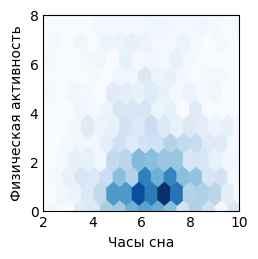

In [19]:

# отбор данных для визуализации плотности распределения отношения
# часы сна - часы физической активности
cursor.execute('SELECT Sleep_Hours FROM mentalhealth')
sleep_data = cursor.fetchall()
cursor.execute('SELECT Physical_Activity_Hrs FROM mentalhealth')
activity_data = cursor.fetchall()

# график
fig, ax = plt.subplots()
ax.hexbin(sleep_data, activity_data, gridsize=20)
ax.set(xlim=(2, 10), ylim=(0, 8))
plt.xlabel('Часы сна')
plt.ylabel('Физическая активность')

plt.show()